In [ ]:
import numpy as np
from emo_utils import *
from sklearn.metrics import ConfusionMatrixDisplay
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, Activation, LSTM, Dropout
import numpy as np
from emo_utils import *
from sklearn.metrics import ConfusionMatrixDisplay
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, Activation, LSTM, Dropout, Embedding



In [3]:
X_train, Y_train = read_csv('data/train_emoji.csv')
X_test, Y_test = read_csv('data/tesss.csv')

In [4]:
# get the maximum number of words in the training set
maxLen = len(max(X_train, key=len).split())

In [5]:
for idx in range(10):
    print(X_train[idx], label_to_emoji(Y_train[idx]))

never talk to me again 😞
I am proud of your achievements 😊
It is the worst day in my life 😞
Miss you so much ❤️
food is life 🍴
I love you mum ❤️
Stop saying bullshit 😞
congratulations on your acceptance 😊
The assignment is too long  😞
I want to go play ⚾


# V1


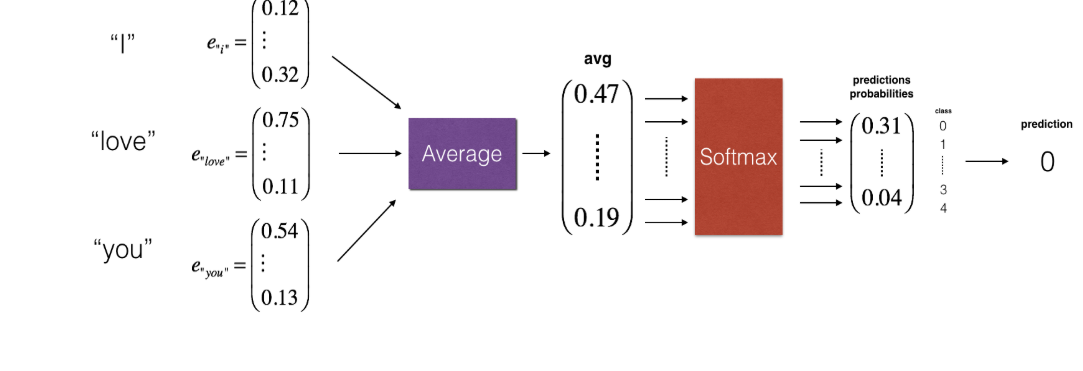

In [6]:
Y_oh_train = convert_to_one_hot(Y_train, C = 5)
Y_oh_test = convert_to_one_hot(Y_test, C = 5)

In [7]:
idx = 10
print(f"Sentence '{X_train[50]}' has label index {Y_train[idx]}, which is emoji {label_to_emoji(Y_train[idx])}", )
print(f"Label index {Y_train[idx]} in one-hot encoding format is {Y_oh_train[idx]}")

Sentence 'I missed you' has label index 3, which is emoji 😞
Label index 3 in one-hot encoding format is [0. 0. 0. 1. 0.]


In [8]:
# Load the word embeddings and use pre-trained 50-dimensional GloVe embeddings.
word_to_index, index_to_word, word_to_vec_map = read_glove_vecs('data/glove.6B.50d.txt')

In [9]:
word = "cucumber"
idx = 289846
print("the index of", word, "in the vocabulary is", word_to_index[word])
print("the", str(idx) + "th word in the vocabulary is", index_to_word[idx])

the index of cucumber in the vocabulary is 113317
the 289846th word in the vocabulary is potatos


In [10]:
def sentence_to_avg(sentence, word_to_vec_map):
    """
    Converts a sentence (string) into a list of words (strings). Extracts the GloVe representation of each word
    and averages its value into a single vector encoding the meaning of the sentence.
    
    Arguments:
    sentence -- string, one training example from X
    word_to_vec_map -- dictionary mapping every word in a vocabulary into its 50-dimensional vector representation
    
    Returns:
    avg -- average vector encoding information about the sentence, numpy-array of shape (50,)
    """
    # Get a valid word contained in the word_to_vec_map. 
    any_word = list(word_to_vec_map.keys())[0]

    words = sentence.lower().split()

    # Initialize the average word vector, that have the same shape as word vectors.
    avg = np.zeros(word_to_vec_map[any_word].shape)

    count = 0

    for w in words:
        if w in word_to_vec_map:
            avg += word_to_vec_map[w]
            count += 1
    if count > 0:
        avg = avg / count

    return avg

In [12]:
def model(X, Y, word_to_vec_map, learning_rate = 0.01, number_of_iterations = 400):
    """
    Implements a softmax classifier using the pre-trained GloVe word embeddings.
    
    Arguments:
    X -- input dataset, of shape (m, 1)
    Y -- labels, of shape (m, 1)
    word_to_vec_map -- dictionary mapping every word in a vocabulary into its 50-dimensional vector representation
    learning_rate -- learning rate for the stochastic gradient descent algorithm
    
    Returns:
    pred -- vector of predictions, numpy-array of shape (m, 1)
    W -- weight matrix of the softmax layer, of shape (50, C)
    b -- bias of the softmax layer, of shape (C,)
    """

    any_word = list(word_to_vec_map.keys())[0]

    cost = 0

    m = X.shape[0] # number of training examples
    C = max(Y) + 1 # number of classes
    n_h = word_to_vec_map[any_word].shape[0] # dimensions of the GloVe vectors

    # Initialize parameters using Xavier initialization.
    W = np.random.randn(n_h, C) / np.sqrt(n_h)
    b = np.zeros((C,))

    Y_oh = convert_to_one_hot(Y, C)

    X_avg = np.array([sentence_to_avg(x, word_to_vec_map) for x in X])

    for t in range(number_of_iterations):
        cost = 0        # Precompute sentence-average vectors once (speeds up training)
        for i in range(m): # Loop over the training examples
            avg = X_avg[i] # Average the word vectors of the words from the i'th training example

            # Forward propagation
            z = np.dot(W.T, avg) + b 
            a = softmax(z)

            # Compute the cost function
            cost -= np.sum(Y_oh[i] * np.log(a))

            # Backpropagation
            dz = a - Y_oh[i]
            dW = np.dot(avg.reshape(-1, 1), dz.reshape(1, -1)) # reshape avg to (n_h, 1) and dz to (1, C) to ensure the correct shape of dW which is (n_h, C) 
            db = dz

            W = W - learning_rate * dW
            b = b - learning_rate * db

        cost = cost / m
        if t % 100 == 0:
            print("Epoch: " + str(t) + " --- cost = " + str(cost))

    return cost, W, b

In [ ]:
np.random.seed(1)
cost, W, b = model(X_train, Y_train, word_to_vec_map,number_of_iterations=500,learning_rate=0.1)
print(cost)

Epoch: 0 --- cost = 1.6804027136338082
Epoch: 100 --- cost = 0.1456295910598817
Epoch: 200 --- cost = 0.10107206606691721
Epoch: 300 --- cost = 0.07689943237536545
Epoch: 400 --- cost = 0.060304708456912784
0.048271800398764296


In [27]:
print("Training set:")
pred_train = predict(X_train, Y_train, W, b, word_to_vec_map)
print('Test set:')
pred_test = predict(X_test, Y_test, W, b, word_to_vec_map)

Training set:
Accuracy: 1.0
Test set:
Accuracy: 0.9107142857142857


In [15]:
def predict_single(sentence, W=W, b=b, word_to_vec_map=word_to_vec_map):
    """
    Given X (sentences) and Y (emoji indices), predict emojis and compute the accuracy of your model over the given set.
    
    Arguments:
    X -- input data containing sentences, numpy array of shape (m, None)
    Y -- labels, containing index of the label emoji, numpy array of shape (m, 1)
    
    Returns:
    pred -- numpy array of shape (m, 1) with your predictions
    """

    any_word = list(word_to_vec_map.keys())[0]
    # number of classes  
    n_h = word_to_vec_map[any_word].shape[0] 
        
    # Split jth test example (sentence) into list of lower case words
    words = sentence.lower().split()

    # Average words' vectors
    avg = np.zeros((n_h,))
    count = 0
    for w in words:
        if w in word_to_vec_map:
            avg += word_to_vec_map[w]
            count += 1

    if count > 0:
        avg = avg / count

    # Forward propagation
    Z = np.dot(W, avg) + b
    A = softmax(Z)
    pred = np.argmax(A)
        
    
    return pred

In [28]:
X_my_sentences = np.array(["i adore you", "i love you", "funny lol", "lets play with a ball", "food is ready", "not feeling happy"])
Y_my_labels = np.array([[0], [0], [2], [1], [4],[3]])

pred = predict(X_my_sentences, Y_my_labels , W, b, word_to_vec_map)
print_predictions(X_my_sentences, pred)

Accuracy: 0.8333333333333334

i adore you ❤️
i love you ❤️
funny lol 😊
lets play with a ball ⚾
food is ready 🍴
not feeling happy 😊


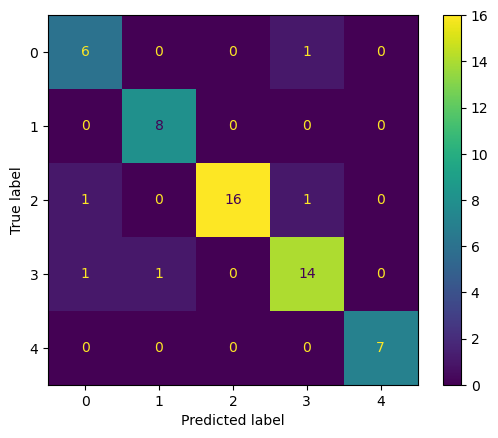

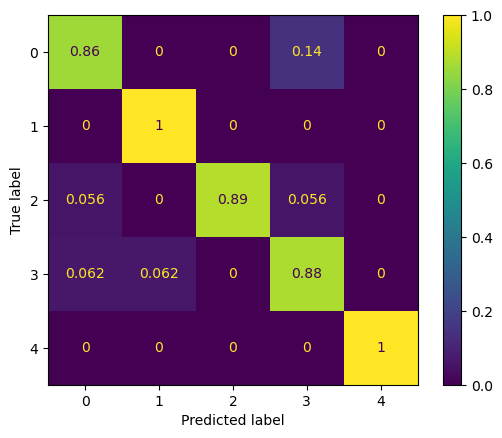

In [ ]:
ConfusionMatrixDisplay.from_predictions(Y_test, pred_test)

# percentages
ConfusionMatrixDisplay.from_predictions(Y_test, pred_test, normalize='true')

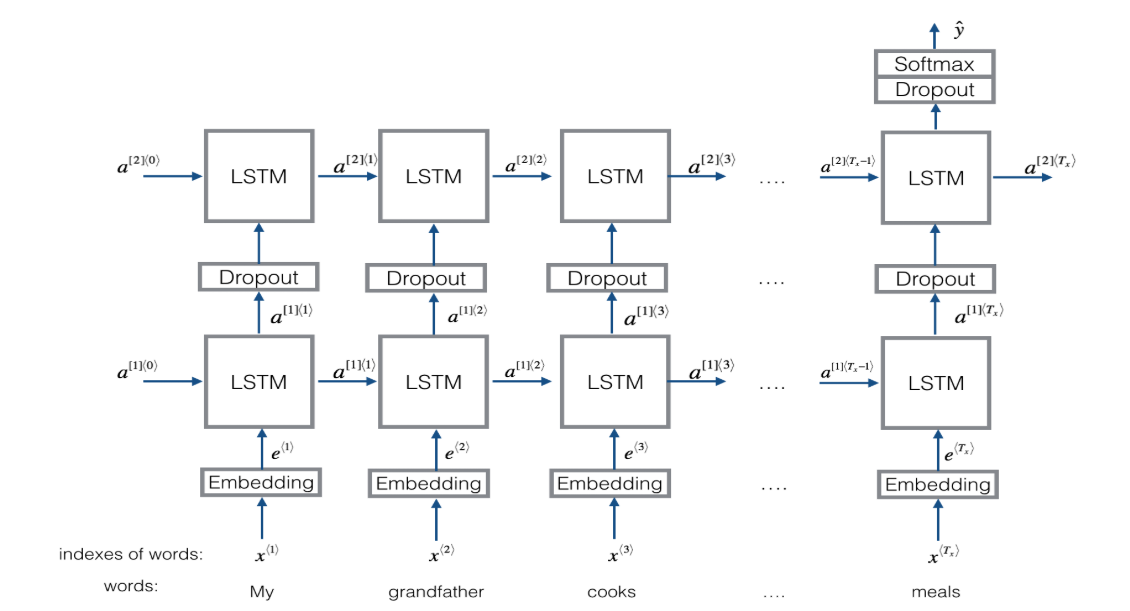

In [33]:
for idx, val in enumerate(["I", "like", "learning"]):
    print(idx, val)

0 I
1 like
2 learning


In [45]:
def sentence_to_indices(X, word_to_index, max_len):
    """
    Converts a sentence (string) into an array of indices corresponding to words in the sentence. The output shape should be (max_len,).
    
    Arguments:
    sentence -- string, one training example from X
    word_to_index -- a dictionary containing the each word in the vocabulary mapped to its index
    max_len -- maximum number of words in a sentence
    
    Returns:
    indices -- array of indices corresponding to words in the sentence, numpy-array of shape (max_len,)
    """
    
    # Initialize indices as a numpy array of zeros and the correct shape (max_len,)
    m = X.shape[0] # number of training examples
    indices = np.zeros([m, max_len])

    for i in range(m): # loop over training examples
        sentence_words = X[i].lower().split()
        j = 0
        for w in sentence_words:
            if w in word_to_index:
                indices[i, j] = word_to_index[w]
                j += 1
    return indices

    

In [46]:
def pretrained_embedding_layer(word_to_vec_map, word_to_index):
    """
    Creates a Keras Embedding() layer and loads in pre-trained GloVe 50-dimensional vectors.
    
    Arguments:
    word_to_vec_map -- dictionary mapping every word in a vocabulary into its 50-dimensional vector representation
    word_to_index -- dictionary mapping from words to their indices in the vocabulary (40000 words)
    
    Returns:
    embedding_layer -- pretrained layer Keras instance
    """
    vocab_len = len(word_to_index) + 1 # adding 1 to fit Keras embedding (unknown words will get index 0)
    emb_dim = word_to_vec_map["cucumber"].shape[0] # define dimensionality of  GloVe word vectors (= 50)

    # Initialize the embedding matrix as a numpy array of zeros of shape (vocab_len, emb_dim)
    emb_matrix = np.zeros((vocab_len, emb_dim))

    # Set each row "index" of the embedding matrix to be the word vector representation of the "index"th word of the vocabulary
    for word, index in word_to_index.items(): 
        emb_matrix[index, :] = word_to_vec_map[word]

    # Define Keras embedding layer with the correct output/input sizes and make it non-trainable.
    embedding_layer = Embedding(vocab_len, emb_dim, trainable=False)

    embedding_layer.build((None,)) # Build the embedding layer, it is required before setting the weights of the embedding layer
    embedding_layer.set_weights([emb_matrix]) # Set the weights of the embedding layer to the embedding matrix

    return embedding_layer

In [ ]:
def Emojify_V2(input_shape, word_to_vec_map, word_to_index):
    """
    Function creating the Emojify-V2 model's graph.
    
    Arguments:
    input_shape -- shape of the input, usually (max_len,)
    word_to_vec_map -- dictionary mapping every word in a vocabulary into its 50-dimensional vector representation
    word_to_index -- dictionary mapping from words to their indices in the vocabulary (40000 words)
    
    Returns:
    model -- a model instance in Keras
    """
    
    # Define the input placeholder for sentences (array of word indices)
    # shape = (max_len,) and dtype=int32 because each word is represented by its index
    sentence_indices = Input(shape=input_shape, dtype='int32')
    
    # Create a pretrained Embedding layer using GloVe vectors
    # Each word index will be mapped to its corresponding 50-dimensional vector
    embedding_layer = pretrained_embedding_layer(word_to_vec_map, word_to_index)
    
    # Pass the input indices through the embedding layer
    # Output 'embeddings' shape = (batch_size, max_len, embedding_dim)
    embeddings = embedding_layer(sentence_indices)
    
    # First LSTM layer with 128 units
    # return_sequences=True to return the hidden state at each timestep
    X = LSTM(128, return_sequences=True)(embeddings)
    
    # Apply dropout to prevent overfitting (drop 50% of units)
    X = Dropout(0.5)(X)
    
    # Second LSTM layer with 128 units
    # return_sequences=False to return only the last hidden state (summary of the sequence)
    X = LSTM(128, return_sequences=False)(X)
    
    # Apply dropout again for regularization
    X = Dropout(0.5)(X)
    
    # Fully connected (Dense) layer with 5 units (number of emoji classes)
    X = Dense(5)(X)
    
    # Softmax activation to get probabilities for each class
    X = Activation('softmax')(X)
    
    # Create Keras model instance
    # Input = sentence_indices, Output = probabilities for each emoji class
    model = Model(inputs=sentence_indices, outputs=X)
    
    return model

In [63]:
model = Emojify_V2((maxLen,), word_to_vec_map, word_to_index)
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 10)]              0         
                                                                 
 embedding_2 (Embedding)     (None, 10, 50)            20000050  
                                                                 
 lstm_4 (LSTM)               (None, 10, 128)           91648     
                                                                 
 dropout_4 (Dropout)         (None, 10, 128)           0         
                                                                 
 lstm_5 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_5 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 5)                 645 

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'], )

In [65]:
X_train_indices = sentence_to_indices(X_train, word_to_index, maxLen)
Y_train_oh = convert_to_one_hot(Y_train, C = 5)

In [114]:
model.fit(X_train_indices, Y_train_oh, epochs = 50, batch_size = 8, shuffle=True)

Epoch 1/50
17/17 [==============================] - 0s 10ms/step - loss: 2.1882e-05 - accuracy: 1.0000
Epoch 2/50
17/17 [==============================] - 0s 9ms/step - loss: 2.5635e-05 - accuracy: 1.0000
Epoch 3/50
17/17 [==============================] - 0s 10ms/step - loss: 2.3320e-05 - accuracy: 1.0000
Epoch 4/50
17/17 [==============================] - 0s 9ms/step - loss: 2.1939e-05 - accuracy: 1.0000
Epoch 5/50
17/17 [==============================] - 0s 9ms/step - loss: 3.0048e-05 - accuracy: 1.0000
Epoch 6/50
17/17 [==============================] - 0s 9ms/step - loss: 4.1372e-05 - accuracy: 1.0000
Epoch 7/50
17/17 [==============================] - 0s 10ms/step - loss: 2.1534e-05 - accuracy: 1.0000
Epoch 8/50
17/17 [==============================] - 0s 10ms/step - loss: 3.4276e-05 - accuracy: 1.0000
Epoch 9/50
17/17 [==============================] - 0s 10ms/step - loss: 2.6797e-05 - accuracy: 1.0000
Epoch 10/50
17/17 [==============================] - 0s 9ms/step - loss: 4.00

In [116]:
X_test_indices = sentence_to_indices(X_test, word_to_index, max_len = maxLen)
Y_test_oh = convert_to_one_hot(Y_test, C = 5)
loss, acc = model.evaluate(X_test_indices, Y_test_oh)
print()
print("Test accuracy = ", acc)

2/2 [==============================] - 0s 8ms/step - loss: 1.0053 - accuracy: 0.8929

Test accuracy =  0.8928571343421936


# mislabelled

In [ ]:
C = 5
y_test_oh = np.eye(C)[Y_test.reshape(-1)]
X_test_indices = sentences_to_indices(X_test, word_to_index, maxLen)
pred = model.predict(X_test_indices)
for i in range(len(X_test)):
    x = X_test_indices
    num = np.argmax(pred[i])
    if(num != Y_test[i]):
        print('Expected emoji:'+ label_to_emoji(Y_test[i]) + ' prediction: '+ X_test[i] + label_to_emoji(num).strip())

2/2 [==============================] - 0s 5ms/step
Expected emoji:😞 prediction: This girl is messing with me	❤️
Expected emoji:😊 prediction: you brighten my day	❤️
Expected emoji:😞 prediction: she is a bully	❤️
Expected emoji:😞 prediction: My life is so boring	❤️
Expected emoji:😞 prediction: go away	⚾


In [ ]:
x_test = np.array(["What are you currently eating ?"])
X_test_indices = sentence_to_indices(x_test, word_to_index, maxLen)
print(x_test[0] +' '+  label_to_emoji(np.argmax(model.predict(X_test_indices))))

1/1 [==============================] - 0s 17ms/step
What are you currently eating ?  🍴
